In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler

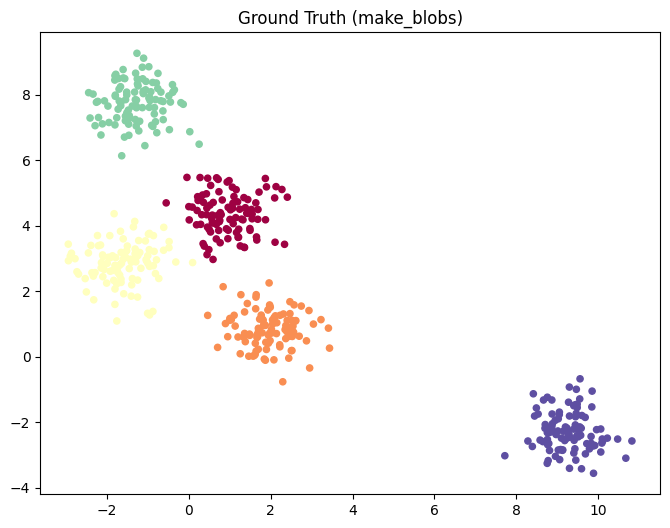

In [28]:
X, y = make_blobs(n_samples=500, n_features=2, centers=5,
                  cluster_std=0.6, random_state=0)

colors = np.array([plt.cm.Spectral(val)
                   for val in np.linspace(0, 1, len(set(y)))])

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=colors[y], s=20)
plt.title('Ground Truth (make_blobs)')
plt.show()

Use albow method to determine the best k for Kmeans

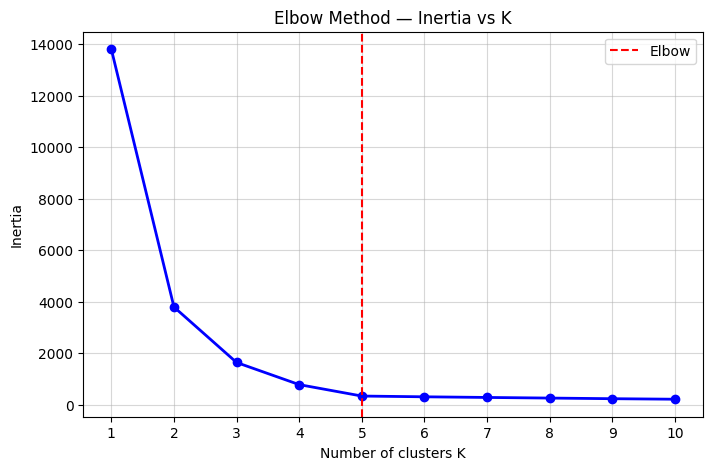

The elbow is at 5, flattens after.


In [29]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o', linewidth=2, color='blue')
plt.axvline(x=5, color='red', linestyle='--', label='Elbow')
plt.title('Elbow Method — Inertia vs K')
plt.xlabel('Number of clusters K')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.legend()
plt.grid(True, linestyle='-', alpha=0.5)
plt.show()

print('The elbow is at 5, flattens after.')

KMeans with Best K

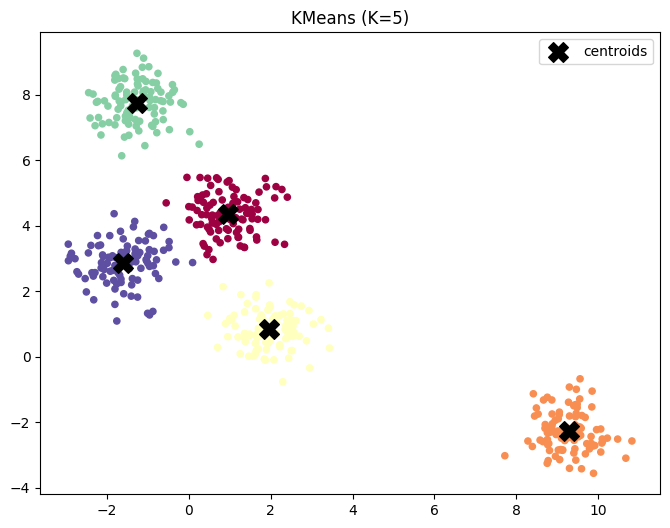

In [30]:
best_k = 5
km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_labels = km.fit_predict(X)

km_colors = np.array([plt.cm.Spectral(val)
                      for val in np.linspace(0, 1, best_k)])

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=km_colors[km_labels], s=20)
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            c='black', marker='X', s=200, zorder=5, label='centroids')
plt.title(f'KMeans (K={best_k})')
plt.legend()
plt.show()

Agglomerative clustering using complete linkage

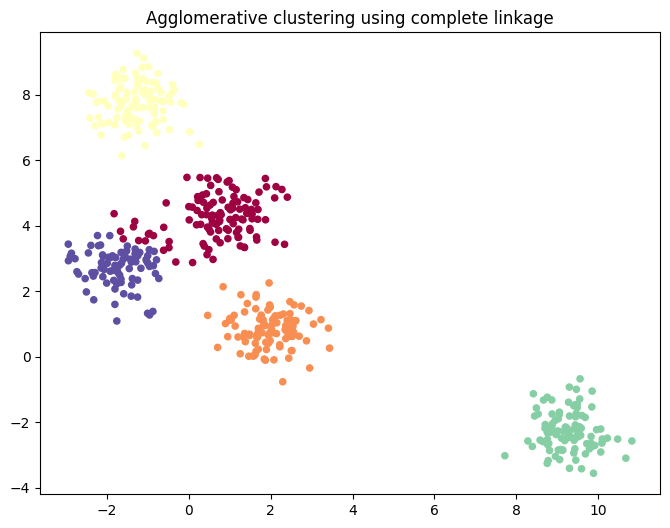

In [31]:
agg_complete = AgglomerativeClustering(n_clusters=5, linkage='complete')
agg_complete_labels = agg_complete.fit_predict(X)

agg_colors = np.array([plt.cm.Spectral(val)
                       for val in np.linspace(0, 1, 5)])

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=agg_colors[agg_complete_labels], s=20)
plt.title('Agglomerative clustering using complete linkage')
plt.show()

Agglomerative clustering using single linkage

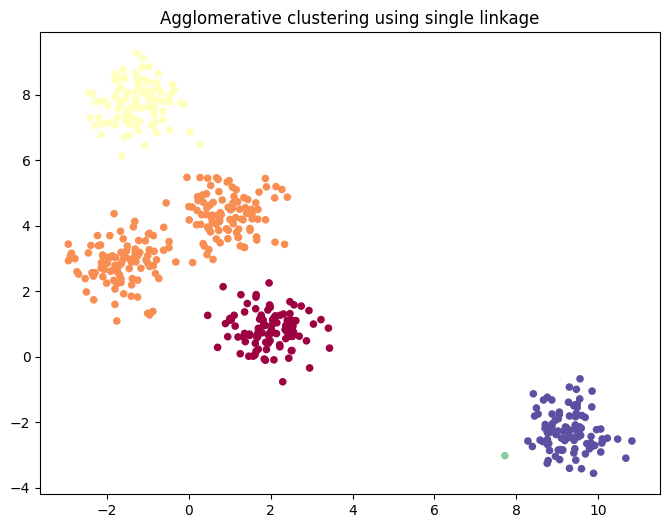

In [32]:
agg_single = AgglomerativeClustering(n_clusters=5, linkage='single')
agg_single_labels = agg_single.fit_predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=agg_colors[agg_single_labels], s=20)
plt.title('Agglomerative clustering using single linkage')
plt.show()

DBSCAN

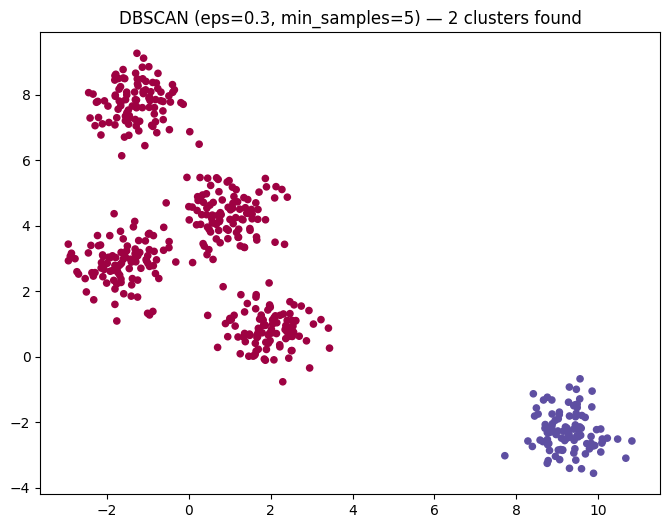

Clusters found: 2
Noise points:   0


In [34]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

dbscan = DBSCAN(eps=0.3, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = np.sum(db_labels == -1)

unique_labels = sorted(set(db_labels))
db_color_map = {}
cluster_ids = [l for l in unique_labels if l != -1]
spectral_colors = [plt.cm.Spectral(val) for val in np.linspace(0, 1, max(len(cluster_ids), 1))]
for i, label in enumerate(cluster_ids):
    db_color_map[label] = spectral_colors[i]
db_color_map[-1] = (0, 0, 0, 1)

point_colors = np.array([db_color_map[l] for l in db_labels])

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=point_colors, s=20)

if n_noise > 0:
    plt.scatter([], [], c='black', s=20, label=f'Noise ({n_noise} pts)')
    plt.legend()

plt.title(f'DBSCAN (eps=0.3, min_samples=5) — {n_clusters_db} clusters found')
plt.show()

print(f'Clusters found: {n_clusters_db}')
print(f'Noise points:   {n_noise}')